In [126]:
# Fig.4c chronology control
# Default uses data-driven first-emergence year per mechanism
# (earliest publication year observed in the dataset).
USE_FIRST_EMERGING_YEAR = True
FIRST_EMERGING_YEAR_FALLBACK = 1956
# Optional manual override. Keys can be canonical mechanism names
# or short labels (for example: {"Spin liq": 1973}).
MECH_YEAR_OVERRIDE = {"Spin liq": 1973}


In [127]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from pathlib import Path
from fig_common import *
import json
import ast
import numpy as np
from collections import defaultdict

LABEL_MAP = {
    'cuprate': 'Cuprates',
    'iron-based': 'Iron-based',
    'heavy-fermion': 'Heavy fermion',
    'elemental': 'Elemental',
    'kagome': 'Kagome',
    'MgB2': r'MgB$_2$',
    'nickelate': 'Nickelates',
    'hydrogen': 'Hydrides',
    'ruthenate': 'Ruthenates'
}

KEEP_FAMS = ['cuprate', 'iron-based', 'heavy-fermion', 'elemental', 'kagome', 'MgB2', 'nickelate', 'hydrogen', 'ruthenate']
OUT_DIR = Path('/home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver')
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_pdf(fig, stem):
    out = OUT_DIR / f'{stem}.pdf'
    fig.savefig(out, format='pdf', bbox_inches='tight')
    print(f'Saved -> {out}')

def parse_json_list(raw):
    if raw is None:
        return []
    txt = str(raw).strip()
    if txt in ('', '[]', 'nan', 'None'):
        return []
    try:
        obj = json.loads(txt)
        return obj if isinstance(obj, list) else []
    except Exception:
        try:
            obj = ast.literal_eval(txt)
            return obj if isinstance(obj, list) else []
        except Exception:
            return []

def build_fam_mech_custom(rows, row_weights):
    mat = np.zeros((len(DISP_FAMS), len(MECH_ORDER)), dtype=float)
    for r, w in zip(rows, row_weights):
        fi = FAM_IDX.get(r.get('family'))
        mi = MECH_IDX.get(r.get('mechanism'))
        if fi is not None and mi is not None:
            mat[fi, mi] += float(w)
    rs = mat.sum(axis=1, keepdims=True)
    rs[rs == 0] = 1.0
    return mat / rs


### Fig.4a
Time-reweighted vs Fig.3 baseline: Family × Mechanism differential map.


Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig4a_family_mechanism_time_weight_shift.pdf


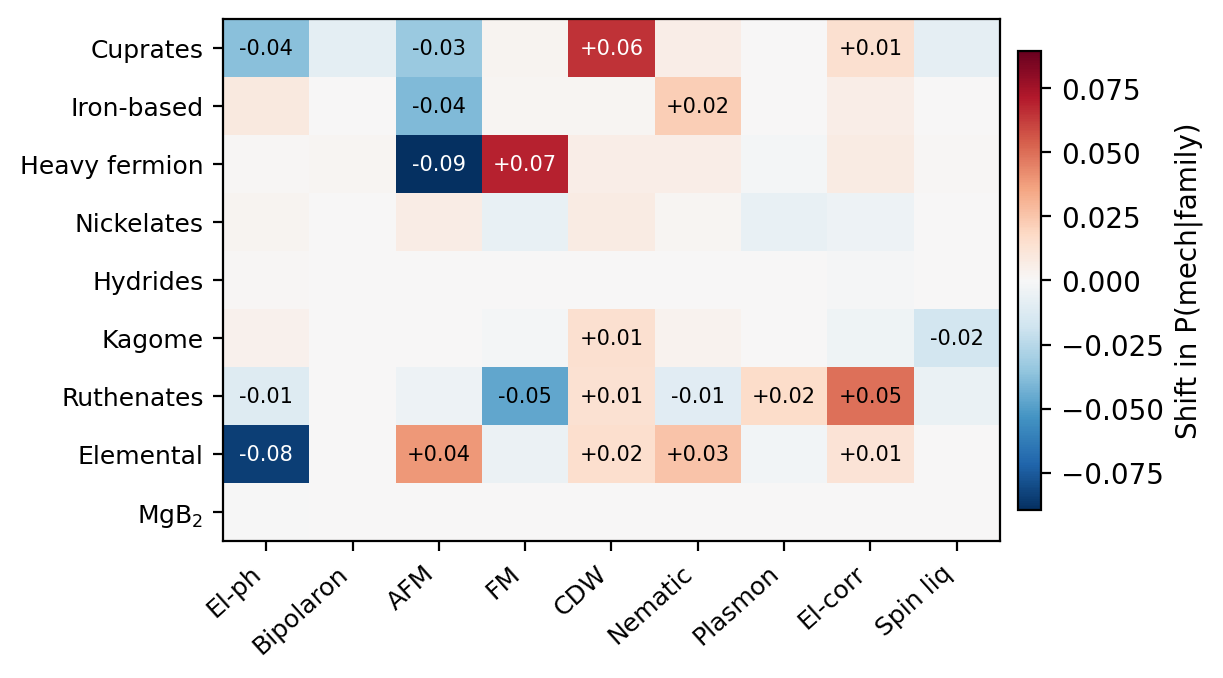

In [128]:
rows = load_rows()

# Baseline from Fig.3 (unweighted)
mat_base = build_fam_mech(rows, flat_weights(rows))

# Time-weighted variant (same definition as make_fig3_5.py)
mat_time = build_fam_mech(rows, time_weights(rows))

# Shift of belief under time weighting
delta = mat_time - mat_base

mask = [f in KEEP_FAMS for f in DISP_FAMS]
delta_f = delta[mask]
y_labels = [LABEL_MAP.get(f, f) for f in np.array(DISP_FAMS)[mask]]
x_labels = [MECH_SHORT[m] for m in MECH_ORDER]

vmax = float(np.max(np.abs(delta_f)))
if vmax <= 1e-12:
    vmax = 1e-3

fig, ax = plt.subplots(figsize=(6.2, 3.5))
draw_heatmap(
    ax,
    delta_f,
    y_labels,
    x_labels,
    cmap='RdBu_r',
    vmin=-vmax,
    vmax=vmax,
    title='Fig. 4a – Time Reweighting Shift\n(ΔP(mech|family) = weighted − baseline)',
    cbar_label='Shift in P(mech|family)',
    annot_frac=0.10,
    diverging=True,
    fmt='+.2f',
)
fig.tight_layout()
save_pdf(fig, 'fig4a_family_mechanism_time_weight_shift')
plt.show()


### Fig.4b
Citation × method-emergence weighted Family × Mechanism map and shift (no theory-evidence reweighting).


Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig4b_family_mechanism_cite_method_weighted_and_shift.pdf
Rows: 5446 mean row weight: 64.1342 nonzero row weight: 5407
Note: no theory-evidence reweighting was applied; only experimental+computational method emergence and citation counts were used.


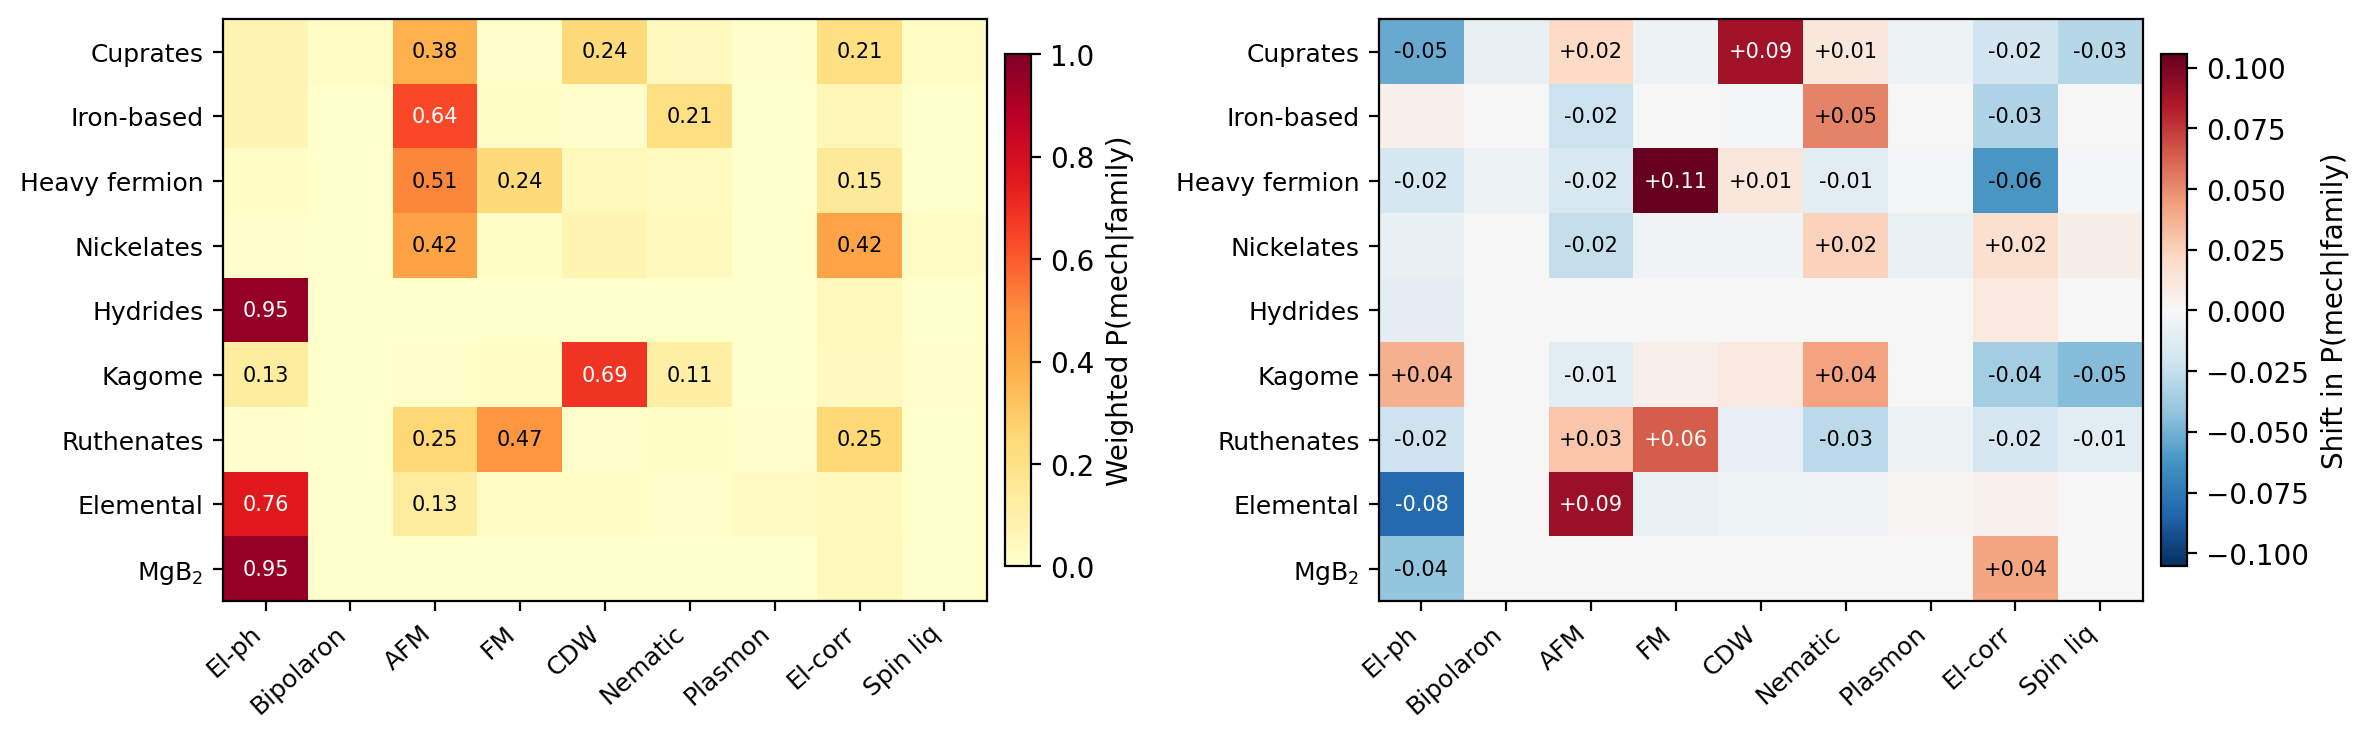

In [129]:
# Core method columns (same method set as make_fig3_per_method_weight.py)
COMPUTATION = [
    'DFT', 'DFPT', 'QMC', 'DMFT', 'Exact Diagonalization', 'DMRG'
]
EXPERIMENT = [
    'Electrical Resistivity / Transport',
    'Magnetic Susceptibility / Magnetization',
    'Tc Measurement',
    'Magnetoresistance / Magnetotransport',
    'Microwave Spectroscopy',
    'Infrared / Optical Spectroscopy',
    'SQUID Magnetometry',
    'Specific Heat / Heat Capacity',
    'Neutron Scattering',
    'ARPES',
    'Josephson Junction Measurements',
    'STM/STS',
    'NMR',
    'Hall Effect',
    'Raman Spectroscopy',
    'muSR',
    'Thermal Conductivity',
    'Quantum Oscillations',
    'XAS',
    'RIXS',
    'EELS',
    'RHEED',
]
METHOD_COLS = COMPUTATION + EXPERIMENT

LAMBDA_METHOD = 0.05
THRESHOLD_N = 5

rows = load_rows()

def parse_year(r):
    try:
        return int(str(r.get('year', '')).strip())
    except Exception:
        return None

def row_methods(r):
    out = []
    for c in METHOD_COLS:
        if str(r.get(c, '0')).strip() == '1':
            out.append(c)
    return out

# Estimate method emergence year by 5th observed paper (same spirit as make_fig3_per_method_weight.py)
method_years = defaultdict(list)
for r in rows:
    y = parse_year(r)
    if y is None:
        continue
    for m in row_methods(r):
        method_years[m].append(y)

method_year_min = {}
for m in METHOD_COLS:
    ys = sorted(method_years.get(m, []))
    if ys:
        method_year_min[m] = ys[min(THRESHOLD_N - 1, len(ys) - 1)]
    else:
        method_year_min[m] = YEAR_MIN

def method_decay_weight(year, method):
    y0 = method_year_min[method]
    if year < y0:
        return 0.0
    return float(np.exp(LAMBDA_METHOD * (year - y0)))

row_w = []
for r in rows:
    y = parse_year(r)
    if y is None:
        row_w.append(0.0)
        continue

    cite_count = len(parse_json_list(r.get("outgoing_internal_citing_papers", "[]")))
    ms = row_methods(r)
    if ms:
        decay = float(np.mean([method_decay_weight(y, m) for m in ms]))
    else:
        decay = 1.0

    # Requested: opinion score weighted by cite_counts * exp-decay(method emergence)
    w = float(cite_count) * decay
    row_w.append(w)

# Build weighted family×mechanism map (no theory-evidence weighting used)
mat_base = build_fam_mech(rows, flat_weights(rows))
mat_cite_method = build_fam_mech_custom(rows, row_w)
delta = mat_cite_method - mat_base

mask = [f in KEEP_FAMS for f in DISP_FAMS]
mat_cite_method_f = mat_cite_method[mask]
delta_f = delta[mask]
y_labels = [LABEL_MAP.get(f, f) for f in np.array(DISP_FAMS)[mask]]
x_labels = [MECH_SHORT[m] for m in MECH_ORDER]

vmax = float(np.max(np.abs(delta_f)))
if vmax <= 1e-12:
    vmax = 1e-3

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

draw_heatmap(
    axes[0],
    mat_cite_method_f,
    y_labels,
    x_labels,
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    title='Fig. 4b-left – Cite×Method Emergence Weighted\nP(mech|family)',
    cbar_label='Weighted P(mech|family)',
    annot_frac=0.10,
)

draw_heatmap(
    axes[1],
    delta_f,
    y_labels,
    x_labels,
    cmap='RdBu_r',
    vmin=-vmax,
    vmax=vmax,
    title='Fig. 4b-right – Shift vs Fig.3 baseline\n(ΔP = weighted − baseline)',
    cbar_label='Shift in P(mech|family)',
    annot_frac=0.10,
    diverging=True,
    fmt='+.2f',
)

fig.tight_layout()
save_pdf(fig, 'fig4b_family_mechanism_cite_method_weighted_and_shift')

print('Rows:', len(rows), 'mean row weight:', round(float(np.mean(row_w)), 4), 'nonzero row weight:', int(np.sum(np.array(row_w) > 0)))
print('Note: no theory-evidence reweighting was applied; only experimental+computational method emergence and citation counts were used.')
plt.show()


In [130]:
from pathlib import Path
import matplotlib.pyplot as plt

FIG4_RAW_DIR = Path('/home/vipandyc/data1/RevGPT/SC_analysis/output/figures_4')
FIG4_FINAL_DIR = Path('/home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver')
FIG4_FINAL_DIR.mkdir(parents=True, exist_ok=True)


def show_and_export_png_as_pdf(png_name, pdf_name, figsize=(9, 6)):
    png_path = FIG4_RAW_DIR / png_name
    if not png_path.exists():
        raise FileNotFoundError(f'Missing generated figure: {png_path}')

    img = plt.imread(png_path)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.axis('off')
    fig.tight_layout()

    out_pdf = FIG4_FINAL_DIR / pdf_name
    fig.savefig(out_pdf, format='pdf', bbox_inches='tight')
    print(f'Saved -> {out_pdf}')
    plt.show()



### Fig.4c
Mechanism evolution network (from `make_fig4_mechanism_evolution.py`).


paper-level edges restricted to MECH_ORDER: 74,367
Mechanism years used for Fig.4c: {'El-ph': 1956, 'Bipolaron': 1979, 'AFM': 1965, 'FM': 1960, 'CDW': 1972, 'Nematic': 1987, 'Plasmon': 1958, 'El-corr': 1961, 'Spin liq': 1973}
ancestry arrows: 7
Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig4c_mechanism_evolution_with_arrows.pdf


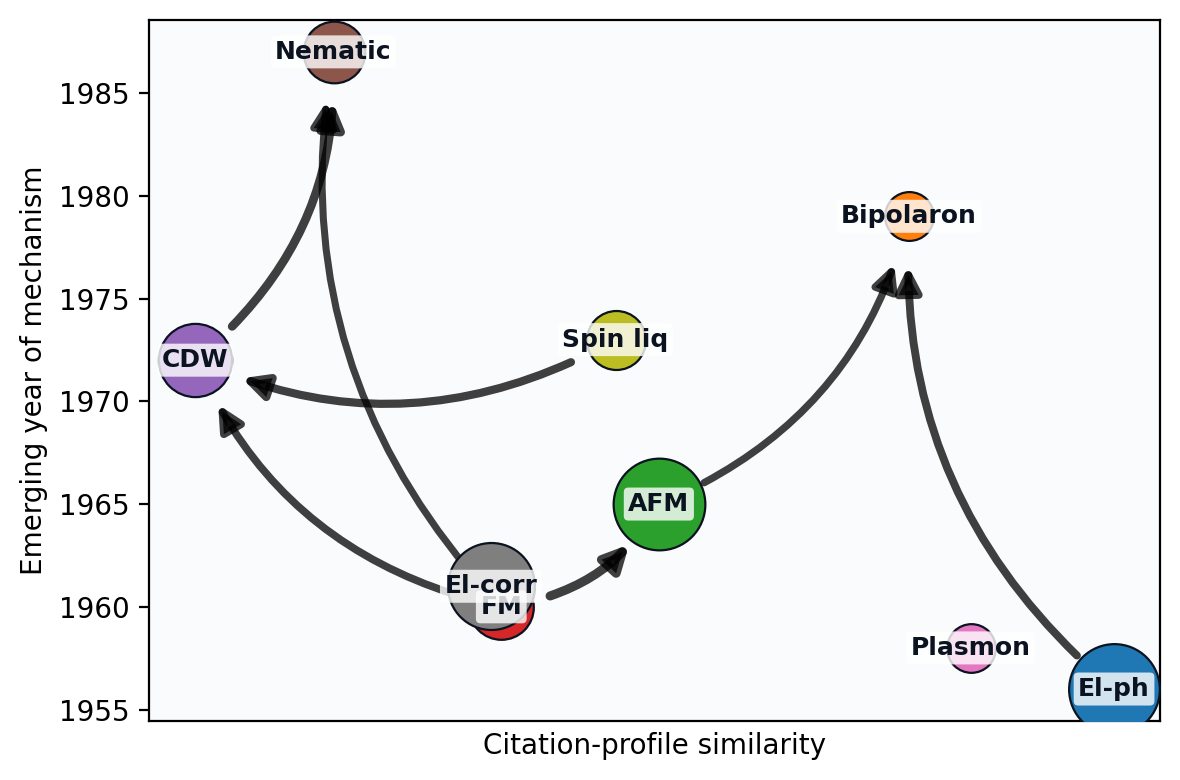

In [131]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

MIN_FLOW = 40
ASYM_RATIO = 0.58
YEAR_SLACK = 5
TOP_K = 3


def parse_cites(s):
    if not isinstance(s, str) or not s.strip():
        return []
    try:
        return list(json.loads(s))
    except Exception:
        return []


df = pd.read_csv(CSV_PATH)
df = df[df["mechanism"].isin(MECH_ORDER)].reset_index(drop=True)

mech_idx = {m: i for i, m in enumerate(MECH_ORDER)}
K = len(MECH_ORDER)

idx_arr = df["mechanism"].map(mech_idx).to_numpy()

X = np.zeros((len(df), K), dtype=np.float64)
X[np.arange(len(df)), idx_arr] = 1.0

id_to_row = {pid: i for i, pid in enumerate(df["id"])}

src_list, tgt_list = [], []
for i, cites in enumerate(df["outgoing_internal_citing_papers"].map(parse_cites)):
    for t in cites:
        j = id_to_row.get(t)
        if j is not None:
            src_list.append(i)   # citing paper
            tgt_list.append(j)   # cited paper

src_arr = np.asarray(src_list)
tgt_arr = np.asarray(tgt_list)

print(f"paper-level edges restricted to MECH_ORDER: {len(src_arr):,}")

# F[i, j] = number of citations from mechanism i papers to mechanism j papers
F = X[src_arr].T @ X[tgt_arr]

years = df["year"].to_numpy(dtype=float)

median_yr = np.array([
    np.median(years[idx_arr == k])
    for k in range(K)
])

first_emerge_yr = np.array([
    np.nanmin(years[idx_arr == k]) if np.any(idx_arr == k) else np.nan
    for k in range(K)
], dtype=float)

use_first_emerge_year = globals().get("USE_FIRST_EMERGING_YEAR", True)
fallback_year = float(globals().get("FIRST_EMERGING_YEAR_FALLBACK", np.nanmedian(median_yr)))

if use_first_emerge_year:
    yr = np.where(np.isfinite(first_emerge_yr), first_emerge_yr, fallback_year)
else:
    yr = median_yr.copy()

year_override = globals().get("MECH_YEAR_OVERRIDE", {}) or {}


def _norm_mech_key(s):
    return "".join(ch for ch in str(s).lower() if ch.isalnum())


override_key_to_mech = {}
for m in MECH_ORDER:
    short = MECH_SHORT.get(m, m)
    for alias in (m, short):
        override_key_to_mech[_norm_mech_key(alias)] = m

# Backward-compatible aliases.
override_key_to_mech.update({
    _norm_mech_key("el-ph"): "pure el-ph coupling",
    _norm_mech_key("bipolaron"): "bipolaron el-ph coupling",
    _norm_mech_key("AFM"): "AFM fluctuation",
    _norm_mech_key("FM"): "FM fluctuation",
    _norm_mech_key("CDW"): "charge density wave",
    _norm_mech_key("nematic"): "nematic fluctuation",
    _norm_mech_key("plasmon"): "plasmon fluctuation",
    _norm_mech_key("el-corr"): "pure el correlation",
    _norm_mech_key("spin_liq"): "spin liquid el correlation",
    _norm_mech_key("spin liq"): "spin liquid el correlation",
})

unmatched_override_keys = []
for raw_key, raw_year in year_override.items():
    m = override_key_to_mech.get(_norm_mech_key(raw_key))
    if m is None:
        unmatched_override_keys.append(str(raw_key))
        continue
    yr[mech_idx[m]] = float(raw_year)

if unmatched_override_keys:
    print("Warning: unmatched MECH_YEAR_OVERRIDE keys:", unmatched_override_keys)

print(
    "Mechanism years used for Fig.4c:",
    {MECH_SHORT.get(m, m): int(round(yr[k])) for k, m in enumerate(MECH_ORDER)},
)

counts = np.array([
    (idx_arr == k).sum()
    for k in range(K)
])

# -----------------------------
# Select directional mechanism edges
# -----------------------------
edges = []

for i in range(K):
    for j in range(K):
        if i == j:
            continue

        fij = F[i, j]
        fji = F[j, i]

        if fij < MIN_FLOW:
            continue

        denom = fij + fji
        if denom <= 0:
            continue

        asym = fij / denom
        if asym < ASYM_RATIO:
            continue

        # Keep only time-consistent citation direction:
        # i = citing mechanism, j = cited mechanism.
        # Usually citing mechanism should not be much older than cited mechanism.
        if yr[i] + YEAR_SLACK < yr[j]:
            continue

        edges.append((i, j, fij, asym))

# Keep top-K strongest cited ancestors per citing mechanism
per_src = {}
for i, j, f, r in edges:
    per_src.setdefault(i, []).append((j, f, r))

edges = []
for i, lst in per_src.items():
    lst.sort(key=lambda t: -t[1])
    for j, f, r in lst[:TOP_K]:
        edges.append((i, j, f, r))

print(f"ancestry arrows: {len(edges)}")

# -----------------------------
# 1D MDS layout from citation-profile similarity
# -----------------------------
row_sums = F.sum(axis=1, keepdims=True)
prof = F / row_sums.clip(min=1)

norms = np.linalg.norm(prof, axis=1).clip(min=1e-9)
cos = (prof @ prof.T) / np.outer(norms, norms)

dist = np.clip(1.0 - cos, 0.0, 2.0)
dist = (dist + dist.T) / 2
np.fill_diagonal(dist, 0.0)

mds = MDS(
    n_components=1,
    dissimilarity="precomputed",
    random_state=7,
    n_init=8,
    normalized_stress="auto",
)

x_coord = mds.fit_transform(dist).flatten()
x_coord = (x_coord - x_coord.min()) / (x_coord.max() - x_coord.min()) * 10

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.set_facecolor("#fafbfc")

# Plot arrows as older cited mechanism -> newer citing mechanism
# This reverses only the visual direction, so arrows point upward in time.
for i, j, f, r in edges:
    x_citing, y_citing = x_coord[i], yr[i]
    x_cited, y_cited = x_coord[j], yr[j]

    rad = 0.25 if x_citing >= x_cited else -0.25
    lw = 1.2 + 3.0 * np.log1p(f) / np.log1p(F.max())

    ax.annotate(
        "",
        xy=(x_citing, y_citing),      # arrow head: newer/citing mechanism
        xytext=(x_cited, y_cited),    # arrow tail: older/cited mechanism
        arrowprops=dict(
            arrowstyle="-|>",
            mutation_scale=18,
            color="black",
            lw=lw,
            alpha=0.75,
            shrinkA=18,
            shrinkB=18,
            connectionstyle=f"arc3,rad={rad}",
        ),
        zorder=2,
    )

# Plot nodes
sizes = 120 + 25 * np.sqrt(counts)

for k, m in enumerate(MECH_ORDER):
    color = MECH_COLORS[m]
    ax.scatter(
        x_coord[k], yr[k], s=sizes[k], c=[color],
        edgecolors="#0b1220", linewidths=0.8, zorder=4,
    )
    ax.text(
        x_coord[k], yr[k], MECH_SHORT.get(m, m), fontsize=9, ha="center", va="center",
        zorder=5, fontweight="bold", color="#0b1220",
        bbox=dict(
            boxstyle="round,pad=0.18",
            fc="white",
            ec="none",
            alpha=0.80,
        ),
    )

ax.set_xlabel(
    "Citation-profile similarity",
    fontsize=10,
)
if use_first_emerge_year:
    y_label = "Emerging year of mechanism"
else:
    y_label = "Median publication year of papers with mechanism"

ax.set_ylabel(
    y_label,
    fontsize=10,
)

#ax.grid(True, axis="y", alpha=0.3, linewidth=0.4)
ax.set_xticks([])

#for sp in ("top", "right"):
#    ax.spines[sp].set_visible(False)

fig.tight_layout()
save_pdf(fig, "fig4c_mechanism_evolution_with_arrows")
plt.show()

### Fig.4d
Mechanism composition alluvial + adjacent-bin citation flows (from `make_fig4_mechanism_alluvial.py`).


Fig.4d y uses relative opinion score per bin (sum of mechanism opinion scores, normalized to 1).
Fig.4d bins: ['1950–1959', '1960–1969', '1970–1979', '1980–1989', '1990–1999', '2000–2009', '2010–2019', '2020–2025']
Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig4d_mechanism_alluvial.pdf


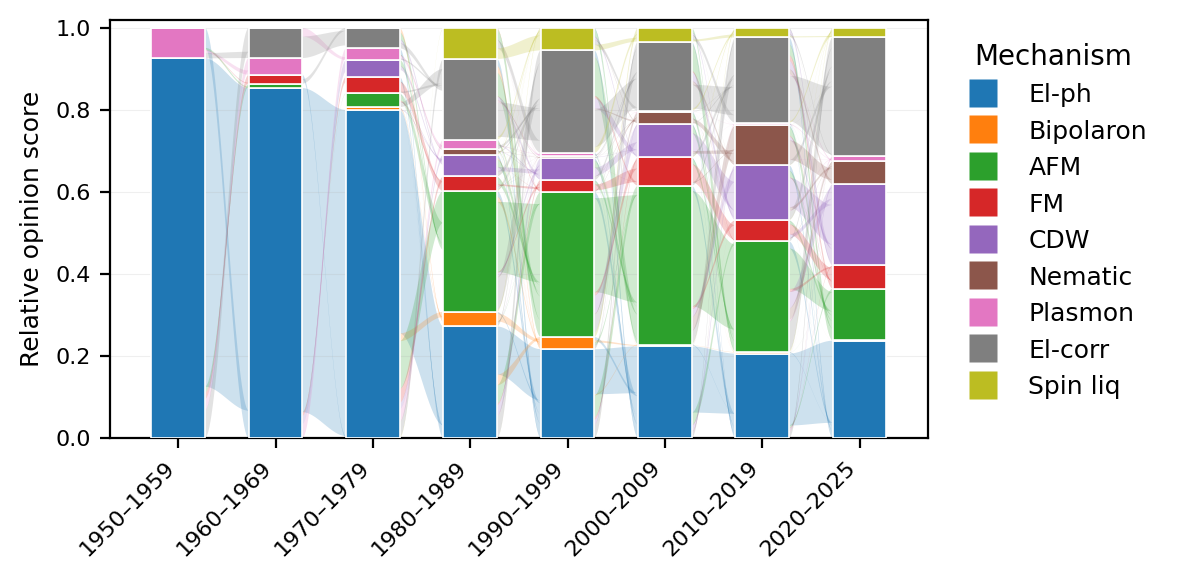

In [132]:
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.path as mpath
import matplotlib.pyplot as plt

BIN_SIZE = 10
FINAL_BIN_START = 2020
FINAL_BIN_END = 2025


def parse_cites(s):
    if not isinstance(s, str) or not s.strip():
        return []
    try:
        return list(json.loads(s))
    except Exception:
        return []


def parse_scores(raw):
    if raw is None:
        return {}
    txt = str(raw).strip()
    if txt in ("", "{}", "nan", "None"):
        return {}
    try:
        return json.loads(txt)
    except Exception:
        try:
            return ast.literal_eval(txt)
        except Exception:
            return {}


def row_mech_score(row):
    scores = parse_scores(row.get('opinion_scores_dict', ''))
    mech = row.get('mechanism')
    try:
        v = float(scores.get(mech, 0.0) or 0.0)
    except Exception:
        v = 0.0
    return max(v, 0.0)


def sigmoid_ribbon(ax, x0, y0a, y0b, x1, y1a, y1b, color, alpha):
    n = 40
    xs = np.linspace(0, 1, n)
    s = xs * xs * (3 - 2 * xs)
    top_y = y0a + (y1a - y0a) * s
    bot_y = y0b + (y1b - y0b) * s
    xs_full = x0 + (x1 - x0) * xs
    verts = list(zip(xs_full, top_y)) + list(zip(xs_full[::-1], bot_y[::-1]))
    codes = [mpath.Path.MOVETO] + [mpath.Path.LINETO] * (len(verts) - 1)
    ax.add_patch(mpatches.PathPatch(mpath.Path(verts, codes), facecolor=color, edgecolor='none', alpha=alpha, linewidth=0))


df = pd.read_csv(CSV_PATH)
df = df[df['mechanism'].isin(MECH_ORDER)].copy()
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df[df['year'].notna()].copy()
df['year'] = df['year'].astype(int)
df = df[df['year'] <= FINAL_BIN_END].copy()

if df.empty:
    raise ValueError('No rows available for Fig.4d after year/mechanism filtering.')

y_min = int(df['year'].min()) // BIN_SIZE * BIN_SIZE
bin_edges = list(range(y_min, FINAL_BIN_START + 1, BIN_SIZE))
if bin_edges[-1] != FINAL_BIN_START:
    bin_edges.append(FINAL_BIN_START)
bin_edges.append(FINAL_BIN_END + 1)
n_bins = len(bin_edges) - 1


def bin_of(y):
    if pd.isna(y):
        return -1
    yi = int(y)
    if yi < bin_edges[0] or yi > FINAL_BIN_END:
        return -1
    return int(np.searchsorted(bin_edges, yi, side='right') - 1)


df['bin'] = df['year'].map(bin_of)
df['mech_score'] = df.apply(row_mech_score, axis=1)

K = len(MECH_ORDER)
mech_idx = {m: i for i, m in enumerate(MECH_ORDER)}

# y-stack now uses opinion score (not paper count)
counts = np.zeros((n_bins, K), dtype=float)
for b, m, s in zip(df['bin'], df['mechanism'], df['mech_score']):
    if b < 0 or s <= 0:
        continue
    counts[b, mech_idx[m]] += s

# Citation ribbons are opinion-score weighted by citing paper mechanism score.
flow = np.zeros((n_bins, K, K), dtype=float)
pid_bin = dict(zip(df['id'], df['bin']))
pid_mech = dict(zip(df['id'], df['mechanism']))
pid_score = dict(zip(df['id'], df['mech_score']))

for src_id, cites in zip(df['id'], df['outgoing_internal_citing_papers'].map(parse_cites)):
    bs = pid_bin.get(src_id, -1)
    ms = pid_mech.get(src_id)
    ws = max(float(pid_score.get(src_id, 0.0) or 0.0), 0.0)
    if bs < 0 or ms is None or ws <= 0:
        continue
    ks = mech_idx[ms]
    for tgt_id in cites:
        bt = pid_bin.get(tgt_id, -1)
        mt = pid_mech.get(tgt_id)
        if bt < 0 or mt is None:
            continue
        if bt == bs - 1:
            kt = mech_idx[mt]
            flow[bs, ks, kt] += ws

fig, ax = plt.subplots(figsize=(6, 3))
ax.set_facecolor('white')
col_w = 0.55
xs = np.arange(n_bins, dtype=float)

col_top = {}
for b in range(n_bins):
    y = 0.0
    total = counts[b].sum()
    if total <= 0:
        continue
    for k in range(K):
        h = counts[b, k] / total
        m = MECH_ORDER[k]
        ax.add_patch(mpatches.Rectangle((xs[b] - col_w / 2, y), col_w, h,
                                        facecolor=MECH_COLORS[m], edgecolor='white', linewidth=0.6, zorder=3))
        col_top[(b, k)] = (y, y + h)
        y += h

for b in range(1, n_bins):
    F = flow[b]
    if F.sum() == 0:
        continue
    src_outgoing = F.sum(axis=1)
    tgt_incoming = F.sum(axis=0)
    tgt_anchor = {k: col_top[(b - 1, k)][1] for k in range(K) if (b - 1, k) in col_top}

    for ks in range(K):
        if src_outgoing[ks] == 0 or (b, ks) not in col_top:
            continue
        src_h = col_top[(b, ks)][1] - col_top[(b, ks)][0]
        if counts[b, ks] <= 0:
            continue
        frac_of_stack = min(1.0, src_outgoing[ks] / max(counts[b, ks], 1e-12))
        src_band_h = src_h * frac_of_stack
        src_top = col_top[(b, ks)][1]

        for kt in range(K):
            v = F[ks, kt]
            if v <= 0 or (b - 1, kt) not in col_top:
                continue
            h_s = (v / src_outgoing[ks]) * src_band_h
            tgt_h = col_top[(b - 1, kt)][1] - col_top[(b - 1, kt)][0]
            if counts[b - 1, kt] <= 0 or tgt_incoming[kt] <= 0:
                continue
            frac_tgt = min(1.0, tgt_incoming[kt] / max(counts[b - 1, kt], 1e-12))
            tgt_band_h = tgt_h * frac_tgt
            h_t = (v / tgt_incoming[kt]) * tgt_band_h

            y0a = src_top
            y0b = src_top - h_s
            y1a = tgt_anchor[kt]
            y1b = y1a - h_t

            sigmoid_ribbon(ax, xs[b] - col_w / 2, y0a, y0b, xs[b - 1] + col_w / 2, y1a, y1b,
                           MECH_COLORS[MECH_ORDER[ks]], 0.22)
            src_top -= h_s
            tgt_anchor[kt] -= h_t

ax.set_xlim(-0.7, n_bins - 0.3)
ax.set_ylim(0.0, 1.02)
ax.set_ylabel('Relative opinion score', fontsize=9)
ax.set_yticks(np.linspace(0, 1, 6))
ax.tick_params(axis='y', labelsize=8)
ax.set_xticks(np.arange(n_bins))
ax.set_xticklabels([f"{bin_edges[b]}–{bin_edges[b + 1] - 1}" for b in range(n_bins)], rotation=45, ha='right', fontsize=8)
ax.grid(True, axis='y', alpha=0.20, linewidth=0.4)

handles = [plt.Line2D([0], [0], marker='s', linestyle='', markerfacecolor=MECH_COLORS[m],
                      markeredgecolor='none', markersize=10, label=MECH_SHORT.get(m, m))
           for m in MECH_ORDER]
ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False,
          fontsize=9, title='Mechanism', title_fontsize=10)

print('Fig.4d y uses relative opinion score per bin (sum of mechanism opinion scores, normalized to 1).')
print('Fig.4d bins:', [f"{bin_edges[b]}–{bin_edges[b + 1] - 1}" for b in range(n_bins)])

# ax.set_title('Fig. 4d – Mechanism composition by year bin (relative opinion score) + adjacent-bin citation flows', fontsize=12)
fig.tight_layout()
save_pdf(fig, 'fig4d_mechanism_alluvial')
plt.show()


### Fig.4e
Mechanism chord/ribbon citation matrix (from `make_fig4_mechanism_chord.py`).


Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig4e_mechanism_chord.pdf


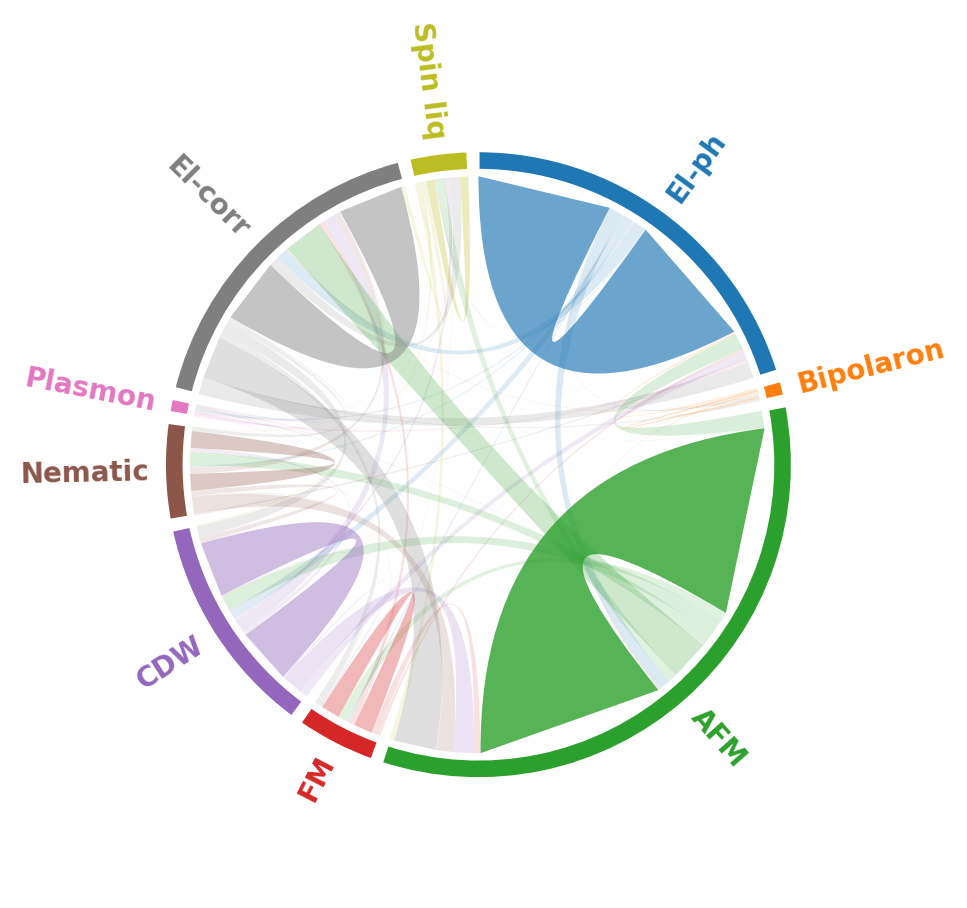

In [133]:
import json
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.path as mpath


def parse_cites(s):
    if not isinstance(s, str) or not s.strip():
        return []
    try:
        return list(json.loads(s))
    except Exception:
        return []


def bezier_ribbon(ax, theta0a, theta0b, theta1a, theta1b, r, color, alpha):
    p0 = np.array([r * np.cos(theta0a), r * np.sin(theta0a)])
    p1 = np.array([r * np.cos(theta0b), r * np.sin(theta0b)])
    p2 = np.array([r * np.cos(theta1a), r * np.sin(theta1a)])
    p3 = np.array([r * np.cos(theta1b), r * np.sin(theta1b)])
    c0 = np.array([0.0, 0.0])
    verts = [tuple(p1), tuple(c0), tuple(p2), tuple(p3), tuple(c0), tuple(p0), tuple(p1)]
    codes = [
        mpath.Path.MOVETO,
        mpath.Path.CURVE3, mpath.Path.CURVE3,
        mpath.Path.LINETO,
        mpath.Path.CURVE3, mpath.Path.CURVE3,
        mpath.Path.CLOSEPOLY,
    ]
    path = mpath.Path(verts, codes)
    ax.add_patch(mpatches.PathPatch(path, facecolor=color, edgecolor='none', alpha=alpha, linewidth=0))


df = pd.read_csv(CSV_PATH)
mech = {pid: m for pid, m in zip(df['id'], df['mechanism'])}

K = len(MECH_ORDER)
idx = {m: i for i, m in enumerate(MECH_ORDER)}
M = np.zeros((K, K), dtype=float)
for pid, cites in zip(df['id'], df['outgoing_internal_citing_papers'].map(parse_cites)):
    ms = mech.get(pid)
    if ms not in idx:
        continue
    i = idx[ms]
    for t in cites:
        mt = mech.get(t)
        if mt not in idx:
            continue
        M[i, idx[mt]] += 1

total = M.sum()
out = M.sum(axis=1)
inc = M.sum(axis=0)
deg = out + inc

GAP = np.deg2rad(2.0)
widths = deg / deg.sum() * (2 * np.pi - GAP * K)

starts = np.zeros(K)
cur = np.pi / 2
for i in range(K):
    starts[i] = cur
    cur -= widths[i] + GAP

R_OUT = 1.00
R_RIB = 0.92

sub_start, sub_end = {}, {}
for i in range(K):
    out_total = out[i]
    inc_total = inc[i]
    inner_arc = widths[i]
    out_arc = inner_arc * (out_total / (out_total + inc_total)) if (out_total + inc_total) else 0
    in_arc = inner_arc - out_arc
    a = starts[i]
    for j in range(K):
        frac = M[i, j] / out_total if out_total else 0
        w = out_arc * frac
        sub_start[(i, 'out', j)] = a
        sub_end[(i, 'out', j)] = a - w
        a -= w
    for j in range(K):
        frac = M[j, i] / inc_total if inc_total else 0
        w = in_arc * frac
        sub_start[(i, 'in', j)] = a
        sub_end[(i, 'in', j)] = a - w
        a -= w

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)
ax.set_aspect('equal')
ax.axis('off')
fig.set_facecolor('white')

for i, m in enumerate(MECH_ORDER):
    theta1 = np.rad2deg(starts[i] - widths[i])
    theta2 = np.rad2deg(starts[i])
    wedge = mpatches.Wedge((0, 0), R_OUT, theta1, theta2, width=0.06,
                           facecolor=MECH_COLORS[m], edgecolor='white', linewidth=0.8, zorder=3)
    ax.add_patch(wedge)
    mid = starts[i] - widths[i] / 2
    lr = 1.05
    ha = 'left' if np.cos(mid) > 0 else 'right'
    rot = np.rad2deg(mid)
    if np.cos(mid) < 0:
        rot += 180
    ax.text(
        lr * np.cos(mid),
        lr * np.sin(mid),
        MECH_SHORT.get(m, m),
        ha=ha,
        va='center',
        fontsize=10,
        rotation=rot,
        rotation_mode='anchor',
        color=MECH_COLORS[m],   # <-- match wedge color
        fontweight='bold'
    )

order_edges = [(i, j, M[i, j]) for i in range(K) for j in range(K) if M[i, j] > 0]
order_edges.sort(key=lambda x: x[2])
m_max = max(v for _, _, v in order_edges)
for i, j, v in order_edges:
    a0 = sub_start[(i, 'out', j)]
    a1 = sub_end[(i, 'out', j)]
    b0 = sub_start[(j, 'in', i)]
    b1 = sub_end[(j, 'in', i)]
    color = MECH_COLORS[MECH_ORDER[i]]
    alpha = 0.12 + 0.55 * (v / m_max)
    if i == j:
        alpha = min(0.80, alpha + 0.15)
    bezier_ribbon(ax, a0, a1, b0, b1, R_RIB, color, alpha)

#ax.set_title(f'Fig. 4e – Mechanism → mechanism internal citations (total edges: {int(total):,})', fontsize=12, pad=14)

fig.tight_layout()
save_pdf(fig, 'fig4e_mechanism_chord')
plt.show()



### Fig.4f
Method co-occurrence backbone network (from `make_fig4_method_cooccurrence.py`).


kept 66 methods, 173 edges
labeling border nodes only: 43 / 66
Saved -> /home/vipandyc/data1/RevGPT/SC_analysis/output/figures_final_ver/fig4f_method_cooccurrence.pdf


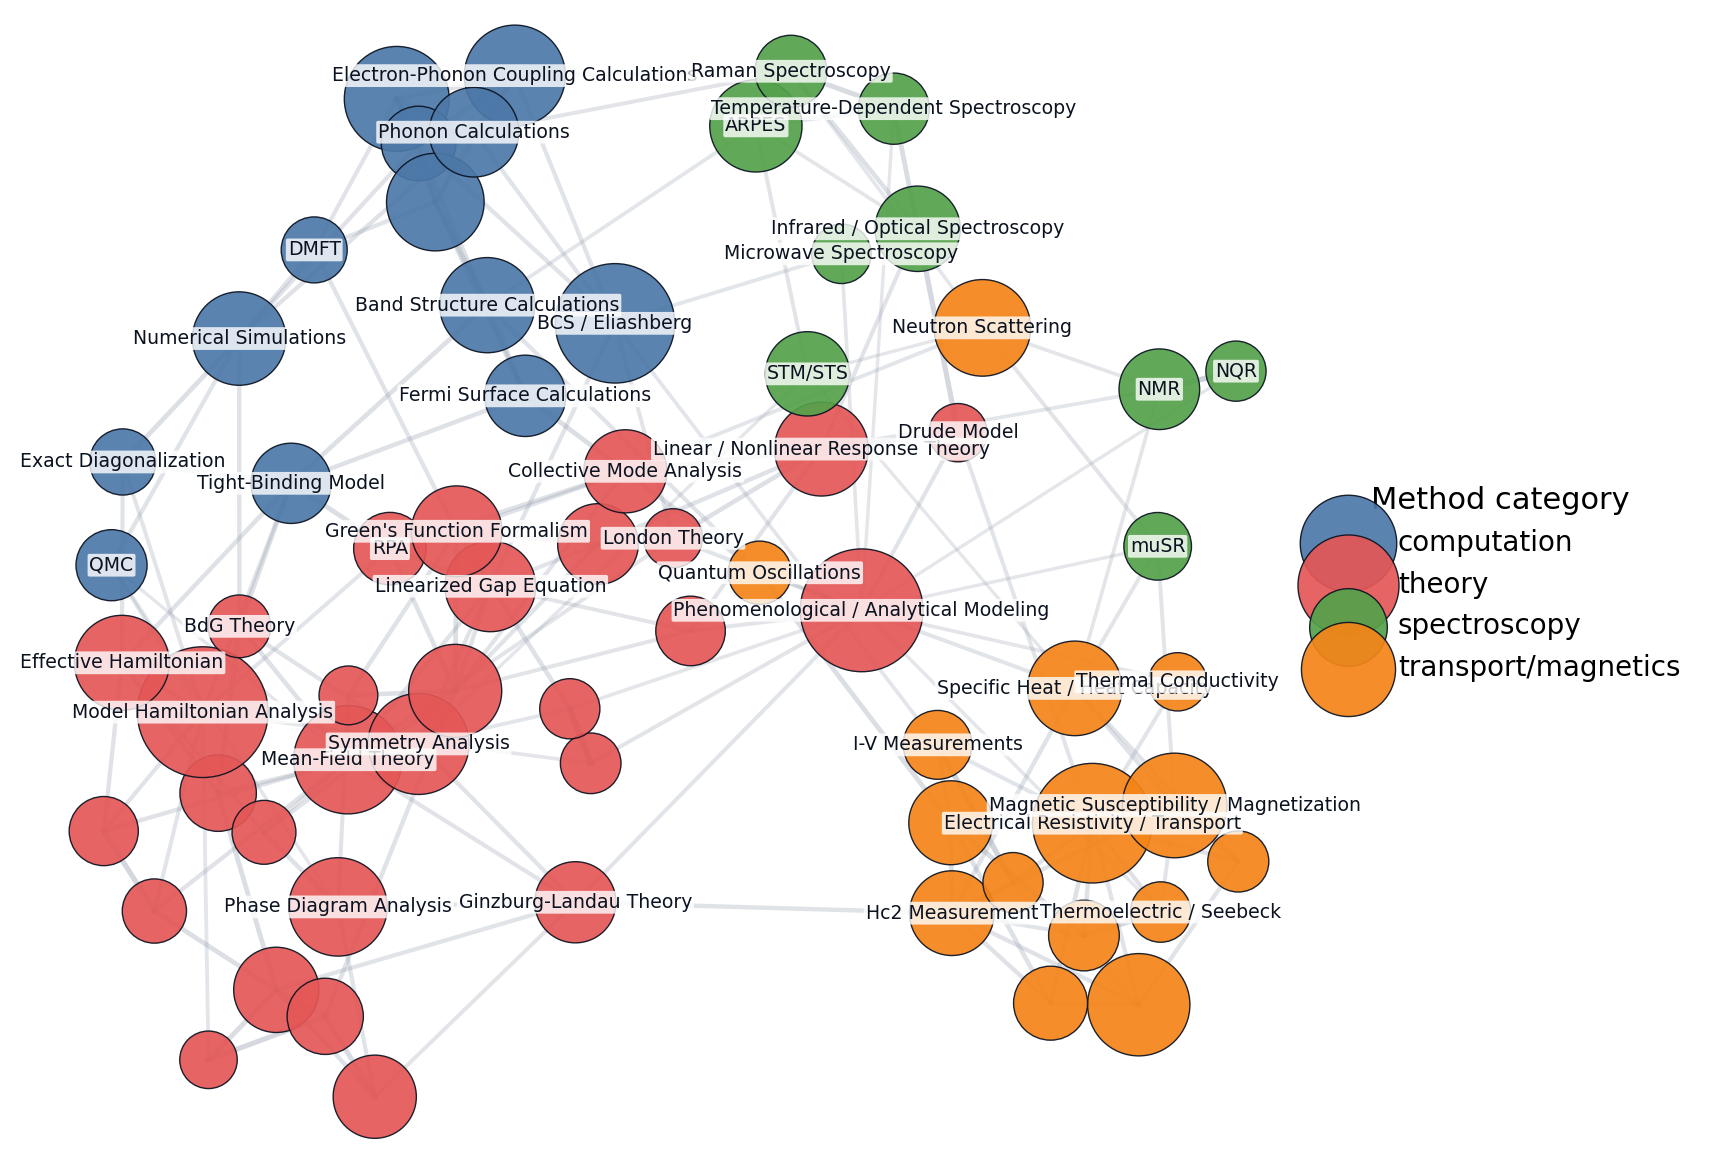

In [134]:
import numpy as np
import pandas as pd
import networkx as nx

# Fig.4g method categories (cleaned mapping)
# - removed categories: conditions/devices, synthesis, microscopy/diffraction
# - merged: STM/STS -> spectroscopy
# - removed explicitly: XRD
CATEGORY = {
    'computation': {
        'DFT', 'DFPT', 'Electron-Phonon Coupling Calculations',
        'Band Structure Calculations', 'Electronic Structure Calculations',
        'Phonon Calculations', 'BCS / Eliashberg', 'DMFT', 'QMC',
        'Monte Carlo Simulations', 'Exact Diagonalization', 'DMRG', 'NRG',
        'FEM', 'Numerical Simulations', 'Tight-Binding Model',
        'Fermi Surface Calculations',
    },
    'theory': {
        'Ginzburg-Landau Theory', 'Mean-Field Theory', 'Effective Field Theory',
        'Symmetry Analysis', 'Linear / Nonlinear Response Theory',
        'Topological Band/Field Theory', 'Scaling Analysis',
        'Model Hamiltonian Analysis', 'Renormalization Group', 'RPA',
        'Perturbation Theory', 'Andreev Theory', 'Josephson Junction Theory',
        'Phenomenological / Analytical Modeling', 'BdG Theory', 'Floquet Theory',
        'Bulk-Boundary Correspondence', 'Luttinger Liquid Theory',
        'Bean Critical-State Model', 'Proximity Effect Theory', 'London Theory',
        'Percolation Theory', 'Bosonization', 'Linear Stability Analysis',
        'Effective Hamiltonian', 'Phase Diagram Analysis',
        'AdS/CFT (Holographic Duality)', 'RVB Theory', 'Two-Fluid Model',
        'Collective Pinning Theory', 'Fermi Liquid Theory', 'Scattering Theory',
        'Collective Mode Analysis', 'Input-Output Theory',
        'Linearized Gap Equation', 'Asymptotic Analysis',
        "Green's Function Formalism", 'Quantum Measurement Theory',
        'Nonlinear Sigma Model', 't-J Model', 'Circuit Quantization',
        'Drude Model', 'Anderson Localization Theory',
    },
    'spectroscopy': {
        'ARPES', 'XPS', 'XAS', 'RIXS', 'EELS', 'FTIR',
        'Infrared / Optical Spectroscopy', 'Microwave Spectroscopy',
        'Mossbauer Spectroscopy', 'ESR/EPR', 'Raman Spectroscopy', 'NMR', 'NQR',
        'muSR', 'Point-Contact Spectroscopy', 'Andreev Reflection Spectroscopy',
        'Temperature-Dependent Spectroscopy',
        'STM/STS',
    },
    'transport/magnetics': {
        'Electrical Resistivity / Transport', 'SQUID Magnetometry',
        'Magnetic Susceptibility / Magnetization', 'Neutron Scattering',
        'Specific Heat / Heat Capacity', 'Tc Measurement', 'Hc2 Measurement',
        'Jc Measurement', 'Magnetoresistance / Magnetotransport', 'Hall Effect',
        'Quantum Oscillations', 'Thermal Conductivity', 'Thermal Expansion',
        'Thermoelectric / Seebeck', 'I-V Measurements',
        'Electrical Resistivity Under Pressure',
    },
}

REMOVED_CONDITIONS_DEVICES = {
    'Temperature-Dependent Measurements', 'Pressure-Dependent Measurements',
    'Magnetic-Field-Dependent Measurements',
    'Magnetic-Field-Dependent Transport', 'Low-Temperature Measurements',
    'Josephson Junction Measurements', 'Circuit QED / Superconducting Qubits',
    'SNSPD', 'Device Fabrication', 'AC Loss Measurements', 'MEG', 'MRI',
    'DLS', 'Electrostatic Gating', 'Cryogenic Testing',
}

REMOVED_SYNTHESIS = {
    'PLD', 'MBE', 'CVD', 'Epitaxial Thin Film Growth',
    'Sample Synthesis / Characterization', 'TGA', 'DTA',
}

REMOVED_MICRO_DIFF = {
    'TEM', 'STM/STS', 'XRD', 'SEM', 'Electron Microscopy (General)',
    'Electron Diffraction', 'RHEED', 'AFM', 'MFM',
    'Scanning SQUID Microscopy', 'Magneto-Optical Imaging', 'EDX',
    'Electron Microprobe Analysis',
}

EXCLUDED_METHODS = (
    REMOVED_CONDITIONS_DEVICES
    | REMOVED_SYNTHESIS
    | REMOVED_MICRO_DIFF
    | {'XRD'}
) - {'STM/STS'}

CAT_COLOR = {
    'computation': '#4c78a8',
    'theory': '#e45756',
    'spectroscopy': '#54a24b',
    'transport/magnetics': '#f58518',
    'other': '#9aa3b2',
}


def cat_of(method):
    for c, members in CATEGORY.items():
        if method in members:
            return c
    return 'other'


df = pd.read_csv(CSV_PATH)
cols = list(df.columns)
method_cols = cols[cols.index('DFT'):cols.index('other')]
method_cols = [m for m in method_cols if m not in EXCLUDED_METHODS]
X = df[method_cols].fillna(0).astype(int).to_numpy()
counts = X.sum(axis=0)
co = X.T @ X
np.fill_diagonal(co, 0)

E = co.sum() / 2
denom = np.outer(counts, counts) / (2 * E + 1e-9)
denom[denom == 0] = np.nan
assoc = co / denom
assoc = np.nan_to_num(assoc, nan=0.0)

MIN_USE = 40
MIN_ASSOC = 2.0
MIN_CO = 15
TOP_EDGES_PER_NODE = 4

# Optional: when True, only label border nodes (nodes with at least one
# cross-category / different-color connection).
LABEL_BORDER_NODES_ONLY = True

keep = np.where(counts >= MIN_USE)[0]
names = [method_cols[i] for i in keep]
sub_assoc = assoc[np.ix_(keep, keep)]
sub_co = co[np.ix_(keep, keep)]
sub_cnt = counts[keep]

cand = []
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        if sub_assoc[i, j] >= MIN_ASSOC and sub_co[i, j] >= MIN_CO:
            cand.append((i, j, float(sub_assoc[i, j]), int(sub_co[i, j])))

keep_edges = set()
adj_by_node = {i: [] for i in range(len(names))}
for i, j, w, c in cand:
    adj_by_node[i].append((j, w))
    adj_by_node[j].append((i, w))
for i, lst in adj_by_node.items():
    lst.sort(key=lambda x: -x[1])
    for j, _ in lst[:TOP_EDGES_PER_NODE]:
        a, b = (i, j) if i < j else (j, i)
        keep_edges.add((a, b))

g = nx.Graph()
for i, m in enumerate(names):
    g.add_node(m, cat=cat_of(m), count=int(sub_cnt[i]))
for i, j, w, c in cand:
    a, b = (i, j) if i < j else (j, i)
    if (a, b) in keep_edges:
        g.add_edge(names[i], names[j], weight=w, raw=c)

iso = [n for n in g.nodes() if g.degree(n) == 0]
g.remove_nodes_from(iso)
print(f'kept {g.number_of_nodes()} methods, {g.number_of_edges()} edges')

k = 1.0 / np.sqrt(max(1, g.number_of_nodes()))
pos = nx.spring_layout(g, k=k, iterations=200, seed=3, weight='weight')

fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0.02, 0.03, 0.78, 0.94])
ax.set_facecolor('#f7f8fb')
ax.set_axis_off()

max_w = max((d['weight'] for _, _, d in g.edges(data=True)), default=1.0)
for u, v, d in g.edges(data=True):
    w = d['weight']
    lw = 0.35 + 1.8 * (np.log1p(w) / np.log1p(max_w))
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
            color='#9aa3b2', lw=lw, alpha=min(0.75, 0.25 + 0.45 * w / max_w), zorder=1)

for cat, color in CAT_COLOR.items():
    nodes = [n for n in g.nodes() if g.nodes[n]['cat'] == cat]
    if not nodes:
        continue
    sizes = [40 + 55 * np.sqrt(g.nodes[n]['count']) for n in nodes]
    xs = [pos[n][0] for n in nodes]
    ys = [pos[n][1] for n in nodes]
    ax.scatter(xs, ys, s=sizes, c=color, edgecolors='#0b1220', linewidths=0.5,
               alpha=0.92, zorder=2, label=cat)

def is_border_node(node):
    c0 = g.nodes[node]['cat']
    for nb in g.neighbors(node):
        if g.nodes[nb]['cat'] != c0:
            return True
    return False


if LABEL_BORDER_NODES_ONLY:
    label_nodes = [n for n in g.nodes() if is_border_node(n)]
    print(f'labeling border nodes only: {len(label_nodes)} / {g.number_of_nodes()}')
else:
    label_nodes = list(g.nodes())

for n in label_nodes:
    ax.text(pos[n][0], pos[n][1], n, fontsize=6.8, ha='center', va='center', zorder=3,
            color='#0b1220', bbox=dict(boxstyle='round,pad=0.10', fc='white', ec='none', alpha=0.80))

ax.legend(loc='center left', bbox_to_anchor=(1.00, 0.5), frameon=False,
          fontsize=10, title='Method category', title_fontsize=11)

save_pdf(fig, 'fig4f_method_cooccurrence')
plt.show()
